In [1]:
# if running on colab:
# !git clone https://github.com/laukamkit/capstone_project_GroupA.git
# cd capstone_project_GroupA/src

In [2]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from NSWData.NSWDataLoader import *
from ModelFiles.ModelPlots import *
nsw_data_loader = NSWDataLoader()

Found NSW data path: C:\Users\kyim1\Desktop\capstone_project_GroupA\data\NSW


In [3]:
sarimax_results_h48_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'sarimax_results', 'sarimax_best_model_h48_test_results.csv'))
sarimax_results_h336_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'sarimax_results', 'sarimax_best_model_h336_test_results.csv'))
sarimax_results_h720_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'sarimax_results', 'sarimax_best_model_h720_test_results.csv'))
gb_results_h48_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'gradient_boosting_results', 'gb_best_model_h48_seed31415_test_results.csv'))
gb_results_h336_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'gradient_boosting_results', 'gb_best_model_h336_seed31415_test_results.csv'))
gb_results_h720_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'gradient_boosting_results', 'gb_best_model_h720_seed31415_test_results.csv'))
lstm_results_h48_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'LSTM_results', 'biLSTM_best_model_h48_lb168_seed31415_test_results.csv'))
lstm_results_h336_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'LSTM_results', 'biLSTM_best_model_h336_lb336_seed31415_test_results.csv'))
lstm_results_h720_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'LSTM_results', 'biLSTM_best_model_h720_lb720_seed31415_test_results.csv'))
patchtst_results_h48_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'patchtst_results', 'patchtst_best_model_h48_seed31415_test_results.csv'))
patchtst_results_h336_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'patchtst_results', 'patchtst_best_model_h336_seed31415_test_results.csv'))
patchtst_results_h720_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'patchtst_results', 'patchtst_best_model_h720_seed31415_test_results.csv'))

# fix timestamps. weird timestamps from google colab.
lstm_results_h48_df['timestamp'] = sarimax_results_h48_df['timestamp']
lstm_results_h336_df['timestamp'] = sarimax_results_h336_df['timestamp']
lstm_results_h720_df['timestamp'] = sarimax_results_h720_df['timestamp']
patchtst_results_h48_df['timestamp'] = sarimax_results_h48_df['timestamp']
patchtst_results_h336_df['timestamp'] = sarimax_results_h336_df['timestamp']
patchtst_results_h720_df['timestamp'] = sarimax_results_h720_df['timestamp']

# create 'origins' for the LSTM and PatchTST results, which are needed for the plots.
lstm_results_h336_df['origins'] = (lstm_results_h336_df['horizon'] == 0).cumsum() - 1
lstm_results_h720_df['origins'] = (lstm_results_h720_df['horizon'] == 0).cumsum() - 1
patchtst_results_h336_df['origins'] = (patchtst_results_h336_df['horizon'] == 0).cumsum() - 1
patchtst_results_h720_df['origins'] = (patchtst_results_h720_df['horizon'] == 0).cumsum() - 1

# overwrite the file with the corrected timestamps
lstm_results_h48_df.to_csv(os.path.join(nsw_data_loader.output_dir, 'LSTM_results', 'biLSTM_best_model_h48_lb168_seed31415_test_results.csv'), index=False)
lstm_results_h336_df.to_csv(os.path.join(nsw_data_loader.output_dir, 'LSTM_results', 'biLSTM_best_model_h336_lb336_seed31415_test_results.csv'), index=False)
lstm_results_h720_df.to_csv(os.path.join(nsw_data_loader.output_dir, 'LSTM_results', 'biLSTM_best_model_h720_lb720_seed31415_test_results.csv'), index=False)
patchtst_results_h48_df.to_csv(os.path.join(nsw_data_loader.output_dir, 'patchtst_results', 'patchtst_best_model_h48_seed31415_test_results.csv'), index=False)
patchtst_results_h336_df.to_csv(os.path.join(nsw_data_loader.output_dir, 'patchtst_results', 'patchtst_best_model_h336_seed31415_test_results.csv'), index=False)
patchtst_results_h720_df.to_csv(os.path.join(nsw_data_loader.output_dir, 'patchtst_results', 'patchtst_best_model_h720_seed31415_test_results.csv'), index=False)

# keep only the rows where 'origins' is a multiple of the forecast horizon divided by 48, to align with the provided forecast's forecast step size of 48.
sarimax_results_h336_df = sarimax_results_h336_df[sarimax_results_h336_df['origins'] % (336 / 48) == 0]
sarimax_results_h720_df = sarimax_results_h720_df[sarimax_results_h720_df['origins'] % (720 / 48) == 0]
gb_results_h336_df = gb_results_h336_df[gb_results_h336_df['origins'] % (336 / 48) == 0]
gb_results_h720_df = gb_results_h720_df[gb_results_h720_df['origins'] % (720 / 48) == 0]
lstm_results_h336_df = lstm_results_h336_df[lstm_results_h336_df['origins'] % (336 / 48) == 0]
lstm_results_h720_df = lstm_results_h720_df[lstm_results_h720_df['origins'] % (720 / 48) == 0]
patchtst_results_h336_df = patchtst_results_h336_df[patchtst_results_h336_df['origins'] % (336 / 48) == 0]
patchtst_results_h720_df = patchtst_results_h720_df[patchtst_results_h720_df['origins'] % (720 / 48) == 0]


In [4]:
forecast_h48_all_windows_df = pd.read_csv(os.path.join(nsw_data_loader.nsw_path, 'test.csv'))
HORIZON_WINDOWS = [f"P{str(i).zfill(2)}" for i in range(1,49)]
forecast_h48_all_windows_df = forecast_h48_all_windows_df[['DATETIME'] + HORIZON_WINDOWS]
result_df = forecast_h48_all_windows_df.copy()
p_cols = [col for col in result_df.columns if col.startswith('P')]

forecast_h48_df = result_df[['DATETIME']].copy()
for k, col in enumerate(p_cols, start=1):
    forecast_h48_df[col] = result_df[col].shift(-(k - 1)).values
forecast_h48_df = forecast_h48_df.dropna().reset_index(drop=True)

# align the provided forecast with the forecast step size of the other models, which is 48.
forecast_h48_df = forecast_h48_df.loc[[i % 48 == 0 for i in range(len(forecast_h48_df))]].reset_index(drop=True)

# unpivot the windows from col to rows
forecast_h48_df = forecast_h48_df.melt('DATETIME').sort_values('DATETIME').reset_index(drop=True).reset_index()
forecast_h48_df.rename(columns={'index': 'horizon', 'DATETIME': 'timestamp', 'value': 'y_pred'}, inplace=True)
forecast_h48_df['horizon'] = forecast_h48_df['horizon'] % 48
forecast_h48_df['timestamp'] = pd.to_datetime(forecast_h48_df['timestamp']) + pd.to_timedelta(forecast_h48_df['horizon']*30, unit='m')
forecast_h48_df['timestamp'] = forecast_h48_df['timestamp'].astype(str)
forecast_h48_df.drop(columns=['variable'], inplace=True)
forecast_h48_df = forecast_h48_df[['timestamp','horizon','y_pred']]
forecast_h48_df = forecast_h48_df.loc[sarimax_results_h48_df.index]
forecast_h48_df.head()

,timestamp,horizon,y_pred
0,2019-03-03 05:00:00,0,6408.91
1,2019-03-03 05:30:00,1,6562.59
2,2019-03-03 06:00:00,2,6673.26
3,2019-03-03 06:30:00,3,6807.27
4,2019-03-03 07:00:00,4,6961.26


In [5]:
results_dict = {
    'SARIMAX': {
        48: sarimax_results_h48_df,
        336: sarimax_results_h336_df,
        720: sarimax_results_h720_df
    },
    'Gradient Boosting': {
        48: gb_results_h48_df,
        336: gb_results_h336_df,
        720: gb_results_h720_df
    },
    'LSTM': {
        48: lstm_results_h48_df,
        336: lstm_results_h336_df,
        720: lstm_results_h720_df
    },
    'PatchTST': {
        48: patchtst_results_h48_df,
        336: patchtst_results_h336_df,
        720: patchtst_results_h720_df
    },
    'ACTUALS': {
            48: sarimax_results_h48_df[['timestamp', 'horizon', 'y_actual']].rename(columns={'y_actual': 'y_pred'}),
            336: sarimax_results_h336_df[['timestamp', 'horizon', 'y_actual']].rename(columns={'y_actual': 'y_pred'}),
            720: sarimax_results_h720_df[['timestamp', 'horizon', 'y_actual']].rename(columns={'y_actual': 'y_pred'})
    }
}

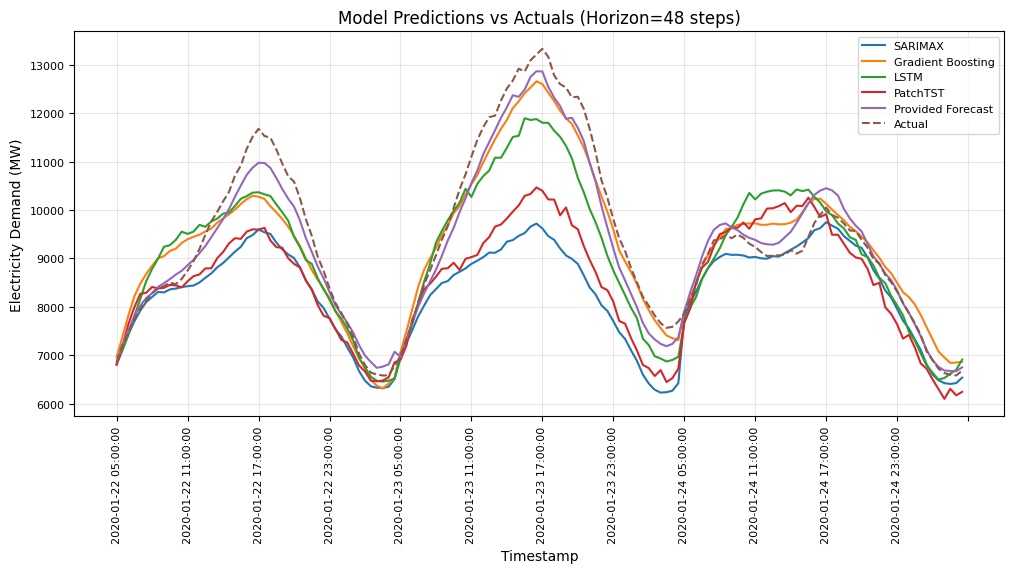

In [8]:
chosen_date_start = '2020-01-22 00:00:00'  # Set this to a date within the range of your results
horizon_to_plot = 48  # Choose from 48, 336, or 720

if horizon_to_plot == 48:
    results_dict['Provided Forecast'] = {48: forecast_h48_df}
else:
    try:
        results_dict.pop('Provided Forecast')
    except:
        pass
plot_predictions(results_dict, horizon_to_plot, chosen_date_start, extra_time_steps=48*2)

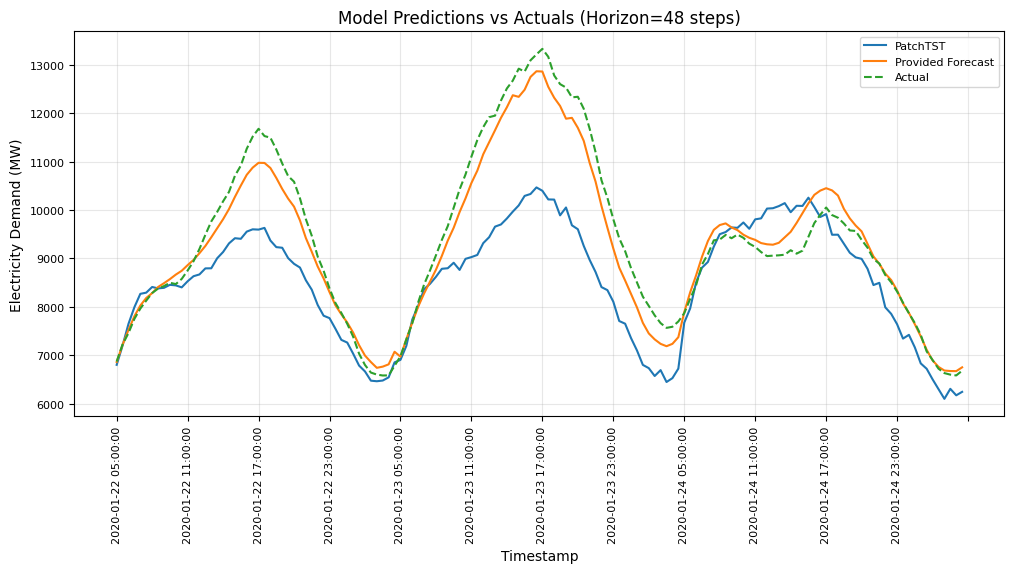

In [9]:
# plot only patchtst, provided forecast and actuals
results_dict_subset = {
    'PatchTST': {
        48: patchtst_results_h48_df
    },
    'Provided Forecast': {
        48: forecast_h48_df
    },
    'ACTUALS': {
        48: sarimax_results_h48_df[['timestamp', 'horizon', 'y_actual']].rename(columns={'y_actual': 'y_pred'})
    }
}
plot_predictions(results_dict_subset, horizon_to_plot, chosen_date_start, extra_time_steps=48*2)

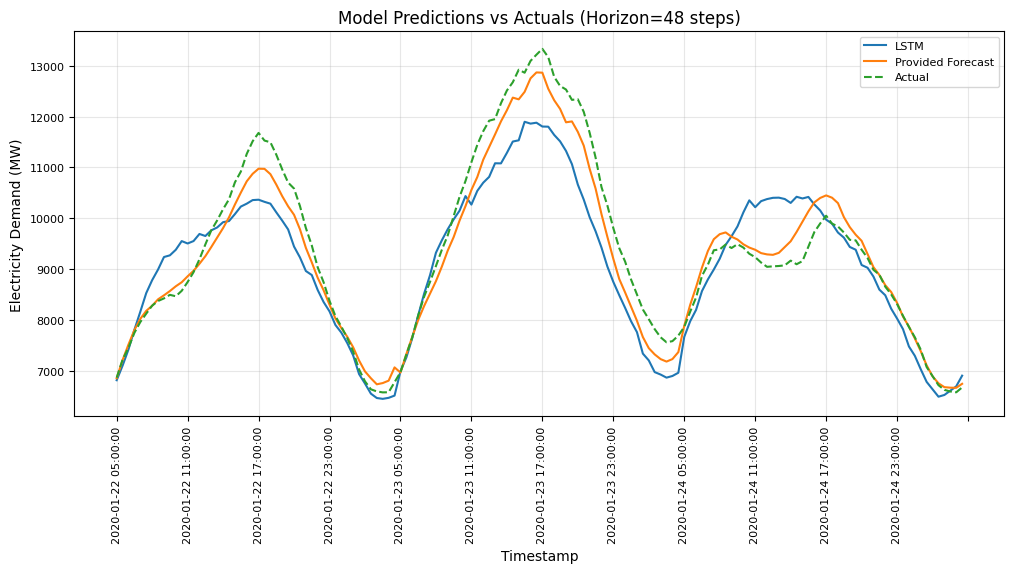

In [10]:
# plot only lstm, provided forecast and actuals
results_dict_subset = {
    'LSTM': {
        48: lstm_results_h48_df
    },
    'Provided Forecast': {
        48: forecast_h48_df
    },
    'ACTUALS': {
        48: sarimax_results_h48_df[['timestamp', 'horizon', 'y_actual']].rename(columns={'y_actual': 'y_pred'})
    }
}
plot_predictions(results_dict_subset, horizon_to_plot, chosen_date_start, extra_time_steps=48*2)

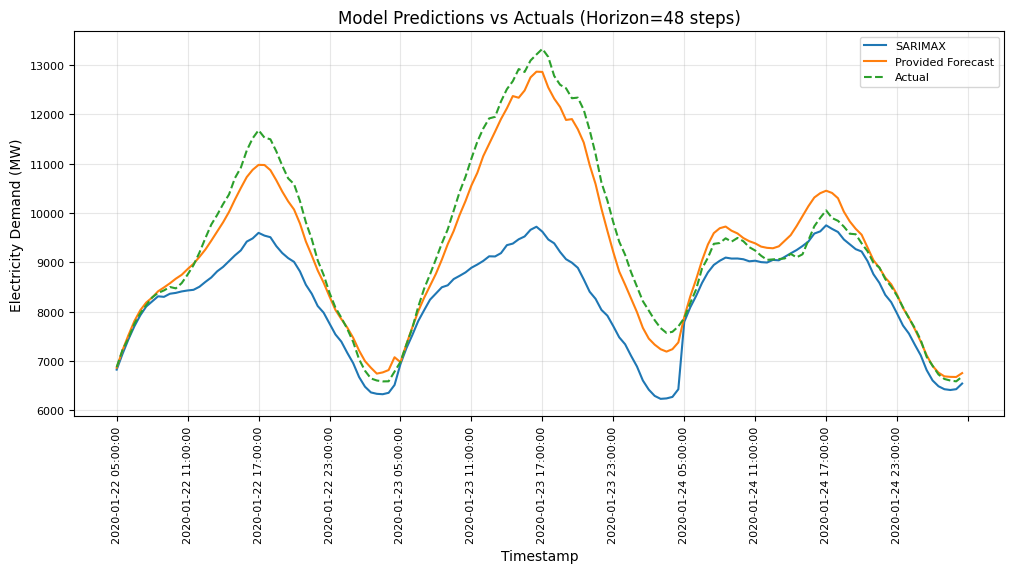

In [11]:
# plot only sarimax, provided forecast and actuals
results_dict_subset = {
    'SARIMAX': {
        48: sarimax_results_h48_df
    },
    'Provided Forecast': {
        48: forecast_h48_df
    },
    'ACTUALS': {
        48: sarimax_results_h48_df[['timestamp', 'horizon', 'y_actual']].rename(columns={'y_actual': 'y_pred'})
    }
}
plot_predictions(results_dict_subset, horizon_to_plot, chosen_date_start, extra_time_steps=48*2)

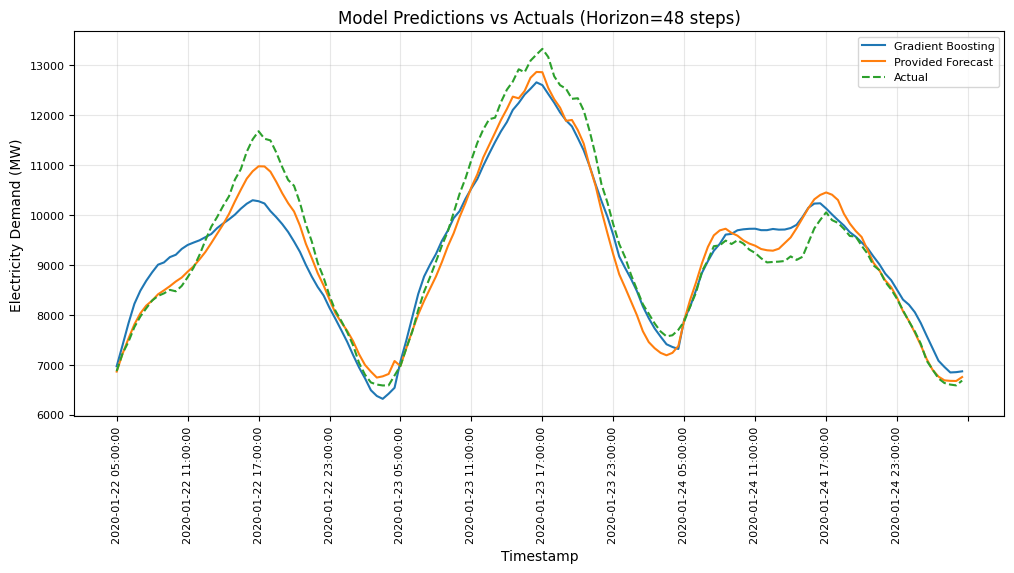

In [12]:
# plot only gradient boosting, provided forecast and actuals
results_dict_subset = {
    'Gradient Boosting': {
        48: gb_results_h48_df
    },
    'Provided Forecast': {
        48: forecast_h48_df
    },
    'ACTUALS': {
        48: gb_results_h48_df[['timestamp', 'horizon', 'y_actual']].rename(columns={'y_actual': 'y_pred'})
    }
}
plot_predictions(results_dict_subset, horizon_to_plot, chosen_date_start, extra_time_steps=48*2)